In [5]:
import os

print(os.getcwd())

c:\Users\kalya\OneDrive\Desktop\CODSOFT_TASKS\Task2_Movie_Rating


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/IMDb Movies India.csv", encoding="latin1")

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
df.shape

(15509, 10)

In [9]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='str')

In [10]:
df.isnull().sum()


Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [11]:
df = df.dropna(subset=["Rating"])

df.shape

(7919, 10)

In [12]:
df["Rating"].describe()


count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64

In [13]:
df.dtypes

Name            str
Year            str
Duration        str
Genre           str
Rating      float64
Votes           str
Director        str
Actor 1         str
Actor 2         str
Actor 3         str
dtype: object

In [14]:
df["Year"] = df["Year"].str.extract(r"(\d{4})").astype(float)

df["Duration"] = df["Duration"].str.extract(r"(\d+)").astype(float)

df["Votes"] = df["Votes"].str.replace(",", "", regex=False).astype(float)

df[["Year", "Duration", "Votes"]].head()

,Year,Duration,Votes
1,2019.0,109.0,8.0
3,2019.0,110.0,35.0
5,1997.0,147.0,827.0
6,2005.0,142.0,1086.0
8,2012.0,82.0,326.0


In [15]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [16]:
df["Duration"] = df["Duration"].fillna(df["Duration"].median())

categorical_columns = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [17]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [18]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997.0,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005.0,142.0,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [19]:
X = df[["Year", "Duration", "Votes", "Genre"]]

y = df["Rating"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7919, 4)
Target shape: (7919,)


In [20]:
X = pd.get_dummies(X, columns=["Genre"], drop_first=True)

print("Features shape after encoding:", X.shape)

Features shape after encoding: (7919, 435)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6335, 435)
Testing data: (1584, 435)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression
MAE: 1.015033292362993
RMSE: 1.276176475661119
R² Score: 0.12399179524629955


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [26]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest
MAE: 0.8587087900332693
RMSE: 1.141526544449275
R² Score: 0.29909568478771587


In [27]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.015033,1.276176,0.123992
1,Random Forest,0.858709,1.141527,0.299096


In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Votes,0.297038
0,Year,0.243761
1,Duration,0.148799
270,Genre_Drama,0.025532
242,Genre_Documentary,0.020419
364,Genre_Horror,0.009690
328,"Genre_Drama, Romance",0.009070
40,"Genre_Action, Drama",0.008844
163,Genre_Comedy,0.007808
410,Genre_Romance,0.007253


In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Votes,0.297038
0,Year,0.243761
1,Duration,0.148799
270,Genre_Drama,0.025532
242,Genre_Documentary,0.020419
364,Genre_Horror,0.009690
328,"Genre_Drama, Romance",0.009070
40,"Genre_Action, Drama",0.008844
163,Genre_Comedy,0.007808
410,Genre_Romance,0.007253


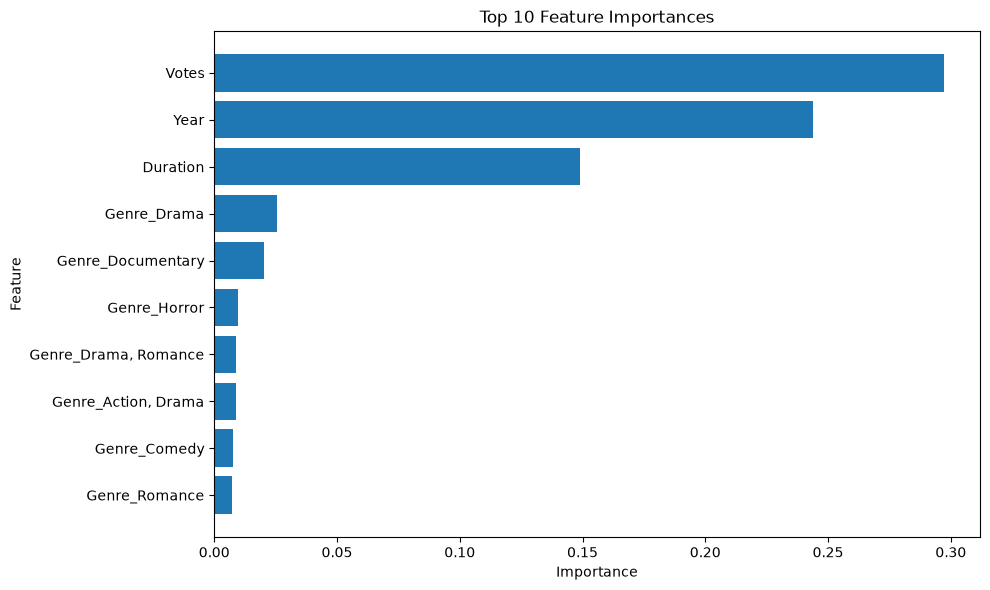

In [32]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

In [33]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(rf_model, "model/movie_rating_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [34]:
sample_movie = pd.DataFrame({
    "Year": [2024],
    "Duration": [140],
    "Votes": [10000],
    "Genre": ["Drama"]
})

sample_movie = pd.get_dummies(
    sample_movie,
    columns=["Genre"],
    drop_first=True
)

sample_movie = sample_movie.reindex(columns=X.columns, fill_value=0)

predicted_rating = rf_model.predict(sample_movie)[0]

print(f"Predicted Movie Rating: {predicted_rating:.2f}")

Predicted Movie Rating: 6.39


In [ ]:
df.shape

(15509, 10)

In [35]:
import joblib

model_data = {
    "model": rf_model,
    "features": list(X.columns)
}

joblib.dump(model_data, "model/movie_rating_model.pkl")

print("Final model and feature information saved successfully!")

Final model and feature information saved successfully!


In [36]:
import os

print(os.path.exists("model/movie_rating_model.pkl"))
print(os.path.getsize("model/movie_rating_model.pkl"), "bytes")

True
53830708 bytes
